<a href="https://colab.research.google.com/github/Ali-Hamza-developer/pytorch/blob/main/04_nn_module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Networks with `torch.nn` — From Simple to Complex


---

In the previous notebook, a single neuron was built completely by hand — manual weights, manual bias, manual gradient updates. This notebook does the same job using PyTorch's built-in `nn.Module`, and shows the idea in **3 stages**, each one a bit more complex than the last:

| Stage | Architecture | What's new |
|---|---|---|
| 1️⃣ Simple | Input → Output | Just `nn.Linear` + `nn.Sigmoid`, no hidden layer |
| 2️⃣ A bit advanced | Input → Hidden (3) → Output | Adds a hidden layer + `nn.ReLU`, built with `nn.Sequential` |
| 3️⃣ More complex | Input → Hidden (8) → Hidden (4) → Output | Deeper network, inspected with `torchinfo` |

Every stage starts with a **diagram** of the architecture before any code, so the shape of the network is clear before reading how it's built.

## 1️⃣ Stage 1 — Simple Neural Network (no hidden layer)

This is the same single-neuron idea as before (logistic regression), but now `nn.Module` handles the weights, bias, and gradients internally — no manual `torch.rand(...)` or manual `.backward()` bookkeeping needed at the model-definition stage.

**Architecture:**
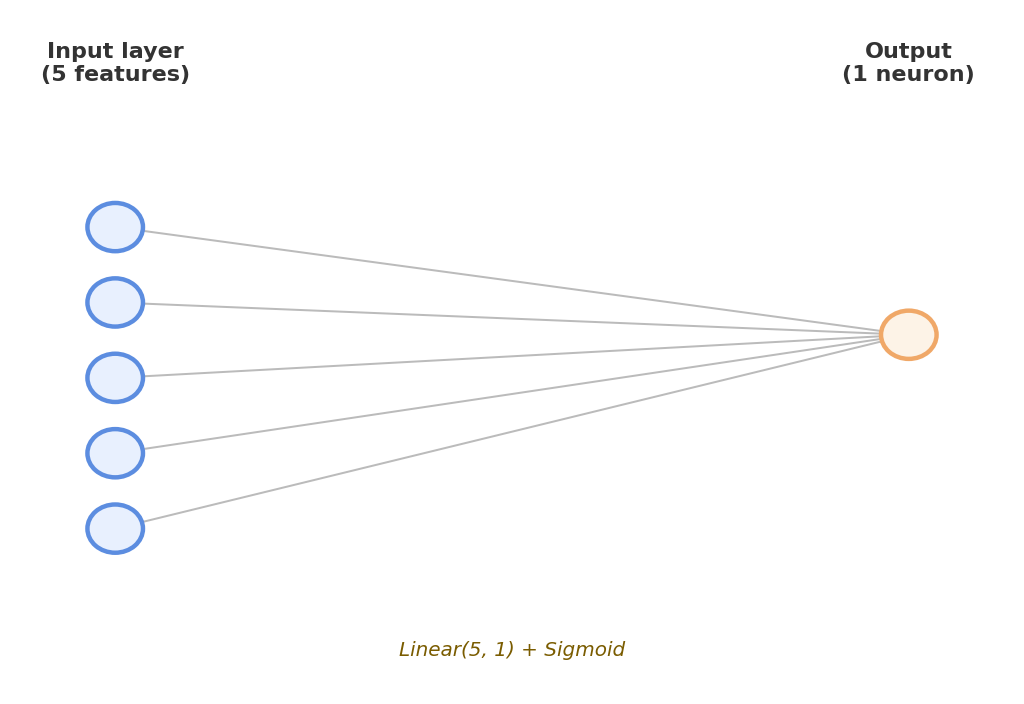

### Building the model

- `nn.Module` is the base class every PyTorch model inherits from
- `super().__init__()` must be called first — it sets up internal bookkeeping (like tracking parameters) that `nn.Module` needs
- `nn.Linear(num_features, 1)` automatically creates the weights **and** bias for you — this replaces the manual `torch.rand(...)` and `torch.zeros(...)` from the earlier notebook
- `forward()` defines what happens when data passes through the model

In [1]:
import torch
import torch.nn as nn

class SimpleModel(nn.Module):

    def __init__(self, num_features):
        super().__init__()
        self.linear = nn.Linear(num_features, 1)   # creates weights + bias automatically
        self.sigmoid = nn.Sigmoid()                 # squashes output into 0-1

    def forward(self, features):
        out = self.linear(features)
        out = self.sigmoid(out)
        return out

### Testing it on some dummy data

`torch.rand(10, 5)` creates 10 random samples, each with 5 features — just to confirm the model runs end-to-end before plugging in real data.

In [2]:
# create dummy dataset: 10 samples, 5 features each
features = torch.rand(10, 5)

# create model
model = SimpleModel(features.shape[1])

# call model for forward pass
model(features)

tensor([[0.5337],
        [0.4947],
        [0.4549],
        [0.5390],
        [0.5120],
        [0.4344],
        [0.5887],
        [0.4303],
        [0.5508],
        [0.4625]], grad_fn=<SigmoidBackward0>)

### Inspecting the learned weights

Every `nn.Linear` layer stores its parameters as `.weight` and `.bias` — no manual tracking needed.

In [3]:
# show model weights
model.linear.weight

Parameter containing:
tensor([[-0.3291, -0.2613, -0.1248,  0.3919,  0.0886]], requires_grad=True)

In [4]:
# show model bias
model.linear.bias

Parameter containing:
tensor([0.1160], requires_grad=True)

---

## 2️⃣ Stage 2 — A Bit More Advanced (one hidden layer)

Now a **hidden layer** is added between input and output. A hidden layer lets the network learn non-linear patterns — a single layer (Stage 1) can only draw a straight decision boundary, but stacking `Linear → ReLU → Linear` lets it bend that boundary.

**Architecture:**
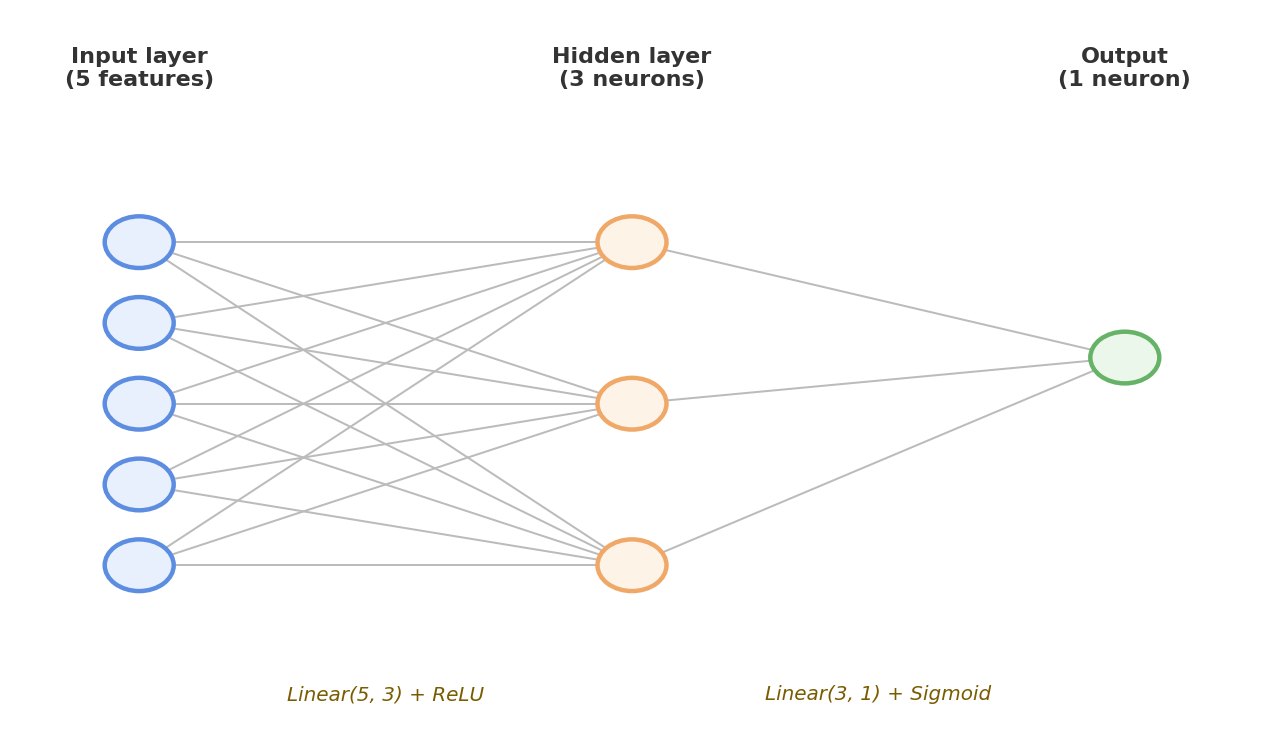

### Building the model with `nn.Sequential`

Instead of defining each layer as a separate attribute, `nn.Sequential` chains layers in order — cleaner to write when the data just flows straight through, layer by layer.

- `nn.Linear(num_features, 3)` — input → 3 hidden neurons
- `nn.ReLU()` — the activation that lets the network learn non-linear patterns (outputs 0 for negative values, passes positive values through unchanged)
- `nn.Linear(3, 1)` — 3 hidden neurons → 1 output
- `nn.Sigmoid()` — squashes the final output into a 0–1 probability

In [5]:
# create model class
import torch
import torch.nn as nn

class Model(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(num_features, 3),
        nn.ReLU(),
        nn.Linear(3, 1),
        nn.Sigmoid()
    )

  def forward(self, features):

    out = self.network(features)

    return out

In [6]:
# create dataset
features = torch.rand(10,5)

# create model
model = Model(features.shape[1])

# call model for forward pass
# model.forward(features)
model(features)

tensor([[0.5528],
        [0.5519],
        [0.5382],
        [0.5344],
        [0.5320],
        [0.5537],
        [0.5606],
        [0.5528],
        [0.5460],
        [0.5367]], grad_fn=<SigmoidBackward0>)

### Inspecting the weights

> ⚠️ **Note:** Layers inside `nn.Sequential` are **not** given attribute names like `linear1` / `linear2` — they're stored by **position**. `self.network` holds 4 layers at indices `0, 1, 2, 3`:
>
> | Index | Layer |
> |---|---|
> | `network[0]` | `Linear(5, 3)` — first linear layer |
> | `network[1]` | `ReLU()` |
> | `network[2]` | `Linear(3, 1)` — second linear layer |
> | `network[3]` | `Sigmoid()` |
>
> So to see the weights, index into `network` rather than using a name like `model.linear2.weight` (that attribute doesn't exist here — it would raise an `AttributeError`).

In [7]:
# show model weights - first Linear layer (index 0 inside the Sequential)
model.network[0].weight

Parameter containing:
tensor([[ 0.2856, -0.0450, -0.0352, -0.2174, -0.2568],
        [ 0.0064,  0.3374,  0.2931, -0.3949,  0.2455],
        [ 0.0773,  0.0821, -0.1384, -0.1259,  0.2279]], requires_grad=True)

In [8]:
# show model weights - second Linear layer (index 2 inside the Sequential)
model.network[2].weight

Parameter containing:
tensor([[-0.2841,  0.1139,  0.0252]], requires_grad=True)

### Inspecting the full architecture with `torchinfo`

`torchinfo` prints a clean summary table of every layer, its output shape, and how many trainable parameters it has — much easier to read than manually checking each `.weight` and `.bias`.

In [9]:
!pip install torchinfo

In [10]:
from torchinfo import summary

summary(model, input_size=(10, 5))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [10, 1]                   --
├─Sequential: 1-1                        [10, 1]                   --
│    └─Linear: 2-1                       [10, 3]                   18
│    └─ReLU: 2-2                         [10, 3]                   --
│    └─Linear: 2-3                       [10, 1]                   4
│    └─Sigmoid: 2-4                      [10, 1]                   --
Total params: 22
Trainable params: 22
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

**Reading the params column:** `Linear(5,3)` has `5×3 + 3 = 18` parameters (weights + bias), and `Linear(3,1)` has `3×1 + 1 = 4` — matching the `18` and `4` in the table, for `22` total trainable parameters.

---

## 3️⃣ Stage 3 — More Complex (two hidden layers)

Same idea, just deeper: two hidden layers instead of one. More layers (and more neurons per layer) let the network represent more complex relationships in the data — at the cost of more parameters to train and a higher chance of overfitting on small datasets.

**Architecture:**
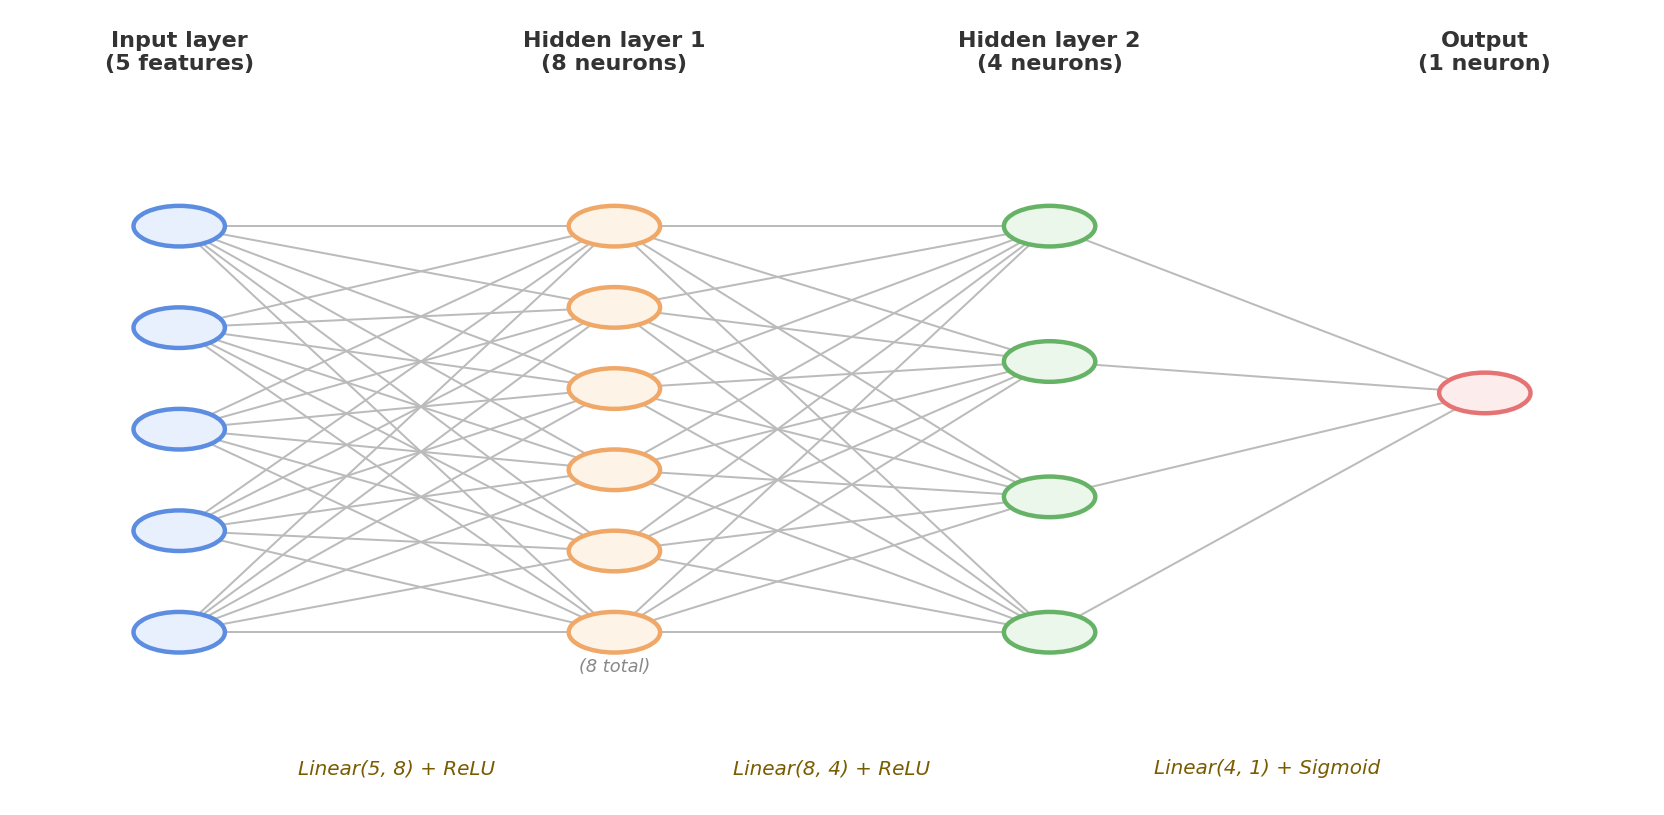

### Building the deeper model

Same pattern as Stage 2 — `nn.Sequential` — just with an extra `Linear + ReLU` block inserted before the output layer:

- `Linear(num_features, 8)` → `ReLU`
- `Linear(8, 4)` → `ReLU`
- `Linear(4, 1)` → `Sigmoid`

> 💡 **On "more features":** Nothing about this class is hardcoded to 5 features — `num_features` is a parameter. Pass in the shape of *any* dataset (for example, `DeepModel(30)` for the 30-feature breast cancer dataset from the earlier notebook) and the first layer adapts automatically. Only the **first** `Linear`'s input size depends on your data; everything after that is your own architecture choice.

In [11]:
# create a deeper model class
import torch
import torch.nn as nn

class DeepModel(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(num_features, 8),
        nn.ReLU(),
        nn.Linear(8, 4),
        nn.ReLU(),
        nn.Linear(4, 1),
        nn.Sigmoid()
    )

  def forward(self, features):

    out = self.network(features)

    return out

In [12]:
# create dataset
features = torch.rand(10, 5)

# create model
model = DeepModel(features.shape[1])

# call model for forward pass
model(features)

tensor([[0.5258],
        [0.5248],
        [0.5244],
        [0.5252],
        [0.5207],
        [0.5278],
        [0.5283],
        [0.5258],
        [0.5260],
        [0.5296]], grad_fn=<SigmoidBackward0>)

### Full architecture summary

Same `torchinfo` call as before — now showing two hidden layers and a larger parameter count.

In [13]:
from torchinfo import summary

summary(model, input_size=(10, 5))

Layer (type:depth-idx)                   Output Shape              Param #
DeepModel                                [10, 1]                   --
├─Sequential: 1-1                        [10, 1]                   --
│    └─Linear: 2-1                       [10, 8]                   48
│    └─ReLU: 2-2                         [10, 8]                   --
│    └─Linear: 2-3                       [10, 4]                   36
│    └─ReLU: 2-4                         [10, 4]                   --
│    └─Linear: 2-5                       [10, 1]                   5
│    └─Sigmoid: 2-6                      [10, 1]                   --
Total params: 89
Trainable params: 89
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

---

## ✅ Summary

- **Stage 1** — one `nn.Linear` + `nn.Sigmoid`: the `nn.Module` equivalent of the manual single neuron
- **Stage 2** — added a hidden layer (`Linear → ReLU → Linear → Sigmoid`) using `nn.Sequential`; learned that Sequential layers are accessed by index, not by name
- **Stage 3** — stacked a second hidden layer to build a deeper network, and used `torchinfo.summary()` to inspect any model's shape and parameter count at a glance
- All three stages accept `num_features` as a parameter, so the exact same classes work on datasets with more (or fewer) input columns — including the 30-feature breast cancer dataset from the earlier notebook



---
**Ali Hamza** · [LinkedIn](https://www.linkedin.com/in/alihamzastudent/)